# Классификация фруктов и овощей по изображению (CNN)

Рубежное задание по курсу «Искусственный интеллект и машинное обучение».

**Задача:** обучить свёрточную нейронную сеть (CNN), которая по фотографии определяет, какой фрукт или овощ на ней изображён.

**Датасет:** [Fruit and Vegetable Image Recognition](https://www.kaggle.com/datasets/kritikseth/fruit-and-vegetable-image-recognition) (Kaggle, автор kritikseth) – 36 классов фруктов и овощей, уже разбит на `train` / `validation` / `test`.

**План ноутбука:**
1. Настройка окружения (Colab, GPU)
2. Загрузка датасета с Kaggle
3. Разведочный анализ: классы, баланс данных
4. Пайплайн данных: аугментация, нормализация, балансировка классов
5. Базовая CNN "с нуля" (baseline)
6. Модель на transfer learning (MobileNetV2)
7. Подбор гиперпараметров
8. Итоговая валидация: confusion matrix, classification report
9. Экспорт модели и словаря классов для веб-сервиса

> Ноутбук рассчитан на запуск в **Google Colab** с GPU-рантаймом (Runtime → Change runtime type → GPU).

## 1. Настройка окружения

Проверяем, что доступен GPU, и импортируем базовые библиотеки.

In [1]:
import tensorflow as tf
print("TensorFlow:", tf.__version__)
print("GPU доступен:", tf.config.list_physical_devices('GPU'))

TensorFlow: 2.20.0
GPU доступен: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [2]:
import os
import json
import shutil
import pathlib
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.utils.class_weight import compute_class_weight

SEED = 42
tf.random.set_seed(SEED)
np.random.seed(SEED)

## 2. Загрузка датасета с Kaggle

Нужен API-токен Kaggle. Получить его можно на странице [kaggle.com/settings](https://www.kaggle.com/settings) → **Create New Token**.

Новый формат токена Kaggle – строка вида `KGAT_...`, которую нужно сохранить в `~/.kaggle/access_token` (старый формат `kaggle.json` с `username`/`key` тоже поддерживается – см. закомментированный вариант ниже).

Запусти ячейку ниже: она попросит вставить токен через безопасное поле ввода (`getpass`), значение не отображается в выводе и не сохраняется в самом ноутбуке.

⚠️ Если ты уже присылал токен где-то в открытом виде (например, в чате) – после того как всё заработает, перевыпусти его на той же странице настроек: старый токен нужно считать скомпрометированным.

In [3]:
from getpass import getpass

kaggle_dir = os.path.expanduser("~/.kaggle")
os.makedirs(kaggle_dir, exist_ok=True)
token_path = os.path.join(kaggle_dir, "access_token")

if not os.path.exists(token_path):
    kaggle_token = getpass("Вставь свой Kaggle API token (KGAT_...): ")
    with open(token_path, "w") as f:
        f.write(kaggle_token.strip())
    os.chmod(token_path, 0o600)
    del kaggle_token
else:
    print("Токен уже сохранён")

# Альтернатива для старого формата kaggle.json (username + key):
# from google.colab import files
# uploaded = files.upload()  # выбери kaggle.json
# shutil.move("kaggle.json", os.path.join(kaggle_dir, "kaggle.json"))
# os.chmod(os.path.join(kaggle_dir, "kaggle.json"), 0o600)

Вставь свой Kaggle API token (KGAT_...): ··········


In [4]:
!pip install -q kaggle
!kaggle datasets download -d kritikseth/fruit-and-vegetable-image-recognition -p /content/data --unzip

Dataset URL: https://www.kaggle.com/datasets/kritikseth/fruit-and-vegetable-image-recognition
License(s): CC0-1.0
100% 1.98G/1.98G [02:14<00:00, 15.8MB/s]



In [5]:
DATA_ROOT = pathlib.Path("/content/data")

# датасет уже приходит в виде train/validation/test с папками-классами внутри
candidates = {p.name.lower(): p for p in DATA_ROOT.iterdir() if p.is_dir()}
print("Найденные папки верхнего уровня:", list(candidates.keys()))

TRAIN_DIR = candidates.get("train")
VAL_DIR = candidates.get("validation") or candidates.get("val")
TEST_DIR = candidates.get("test")

assert TRAIN_DIR and VAL_DIR and TEST_DIR, "Не удалось найти train/validation/test – проверь структуру распакованного архива"
print("train:", TRAIN_DIR)
print("validation:", VAL_DIR)
print("test:", TEST_DIR)

Найденные папки верхнего уровня: ['validation', 'train', 'test']
train: /content/data/train
validation: /content/data/validation
test: /content/data/test


## 3. Разведочный анализ данных

Смотрим список классов и баланс количества изображений по классам (для выявления дисбаланса перед обучением).

In [6]:
class_names = sorted([p.name for p in TRAIN_DIR.iterdir() if p.is_dir()])
NUM_CLASSES = len(class_names)
print(f"Количество классов: {NUM_CLASSES}")
print(class_names)

Количество классов: 36
['apple', 'banana', 'beetroot', 'bell pepper', 'cabbage', 'capsicum', 'carrot', 'cauliflower', 'chilli pepper', 'corn', 'cucumber', 'eggplant', 'garlic', 'ginger', 'grapes', 'jalepeno', 'kiwi', 'lemon', 'lettuce', 'mango', 'onion', 'orange', 'paprika', 'pear', 'peas', 'pineapple', 'pomegranate', 'potato', 'raddish', 'soy beans', 'spinach', 'sweetcorn', 'sweetpotato', 'tomato', 'turnip', 'watermelon']


Всего train: 3115
Всего validation: 351
Всего test: 359


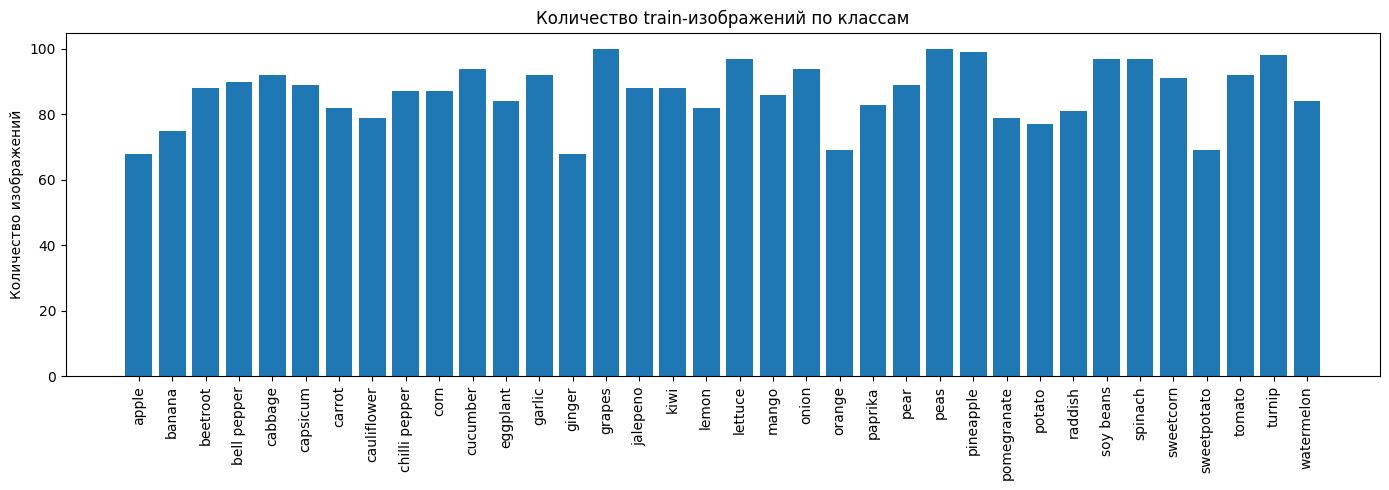

In [7]:
def count_images(split_dir, classes):
    counts = {}
    for c in classes:
        folder = split_dir / c
        counts[c] = len(list(folder.glob("*"))) if folder.exists() else 0
    return counts

train_counts = count_images(TRAIN_DIR, class_names)
val_counts = count_images(VAL_DIR, class_names)
test_counts = count_images(TEST_DIR, class_names)

print("Всего train:", sum(train_counts.values()))
print("Всего validation:", sum(val_counts.values()))
print("Всего test:", sum(test_counts.values()))

plt.figure(figsize=(14, 5))
plt.bar(train_counts.keys(), train_counts.values())
plt.xticks(rotation=90)
plt.title("Количество train-изображений по классам")
plt.ylabel("Количество изображений")
plt.tight_layout()
plt.show()

Если распределение классов заметно неравномерное – компенсируем это на этапе обучения через `class_weight` (см. раздел 4.3), а не через ручное дублирование файлов.

## 4. Пайплайн данных

### 4.1 Загрузка изображений в `tf.data.Dataset`

In [8]:
IMG_SIZE = (224, 224)
BATCH_SIZE = 32

train_ds = tf.keras.utils.image_dataset_from_directory(
    TRAIN_DIR,
    labels="inferred",
    label_mode="categorical",
    class_names=class_names,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    seed=SEED,
    shuffle=True,
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    VAL_DIR,
    labels="inferred",
    label_mode="categorical",
    class_names=class_names,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=False,
)

test_ds = tf.keras.utils.image_dataset_from_directory(
    TEST_DIR,
    labels="inferred",
    label_mode="categorical",
    class_names=class_names,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=False,
)

Found 3115 files belonging to 36 classes.
Found 351 files belonging to 36 classes.
Found 359 files belonging to 36 classes.


### 4.2 Аугментация и нормализация

Аугментация (случайный флип/поворот/зум/контраст) применяется **только к train** и только во время обучения – как слои модели, поэтому она не искажает validation/test и не требует хранения копий файлов на диске.

Нормализация – приведение пикселей из `[0, 255]` в `[0, 1]`.

In [9]:
data_augmentation = tf.keras.Sequential([
    tf.keras.layers.RandomFlip("horizontal"),
    tf.keras.layers.RandomRotation(0.15),
    tf.keras.layers.RandomZoom(0.15),
    tf.keras.layers.RandomContrast(0.15),
], name="data_augmentation")

normalization = tf.keras.layers.Rescaling(1. / 255)

AUTOTUNE = tf.data.AUTOTUNE
train_ds = train_ds.cache().shuffle(1000).prefetch(AUTOTUNE)
val_ds = val_ds.cache().prefetch(AUTOTUNE)
test_ds = test_ds.cache().prefetch(AUTOTUNE)

### 4.3 Балансировка классов

Считаем веса классов по частоте в train и передадим их в `model.fit(..., class_weight=...)`, чтобы редкие классы не игнорировались моделью.

In [10]:
labels_flat = []
for c in class_names:
    labels_flat += [c] * train_counts[c]

class_weights_arr = compute_class_weight(
    class_weight="balanced",
    classes=np.array(class_names),
    y=np.array(labels_flat),
)
class_weight = {i: w for i, w in enumerate(class_weights_arr)}
print(class_weight)

{0: np.float64(1.2724673202614378), 1: np.float64(1.1537037037037037), 2: np.float64(0.983270202020202), 3: np.float64(0.9614197530864198), 4: np.float64(0.9405193236714976), 5: np.float64(0.9722222222222222), 6: np.float64(1.0552168021680217), 7: np.float64(1.0952883263009845), 8: np.float64(0.9945721583652618), 9: np.float64(0.9945721583652618), 10: np.float64(0.9205082742316785), 11: np.float64(1.0300925925925926), 12: np.float64(0.9405193236714976), 13: np.float64(1.2724673202614378), 14: np.float64(0.8652777777777778), 15: np.float64(0.983270202020202), 16: np.float64(0.983270202020202), 17: np.float64(1.0552168021680217), 18: np.float64(0.8920389461626576), 19: np.float64(1.0061369509043927), 20: np.float64(0.9205082742316785), 21: np.float64(1.2540257648953301), 22: np.float64(1.0425033467202143), 23: np.float64(0.9722222222222222), 24: np.float64(0.8652777777777778), 25: np.float64(0.8740179573512907), 26: np.float64(1.0952883263009845), 27: np.float64(1.1237373737373737), 28: 

## 5. Baseline CNN "с нуля"

Небольшая свёрточная сеть без предобученных весов – точка отсчёта для сравнения с transfer learning.

In [11]:
def build_baseline_cnn(num_classes):
    inputs = tf.keras.Input(shape=(*IMG_SIZE, 3))
    x = data_augmentation(inputs)
    x = normalization(x)

    for filters in [32, 64, 128, 256]:
        x = tf.keras.layers.Conv2D(filters, 3, padding="same", activation="relu")(x)
        x = tf.keras.layers.BatchNormalization()(x)
        x = tf.keras.layers.MaxPooling2D()(x)

    x = tf.keras.layers.GlobalAveragePooling2D()(x)
    x = tf.keras.layers.Dense(256, activation="relu")(x)
    x = tf.keras.layers.Dropout(0.4)(x)
    outputs = tf.keras.layers.Dense(num_classes, activation="softmax")(x)

    return tf.keras.Model(inputs, outputs, name="baseline_cnn")

baseline_model = build_baseline_cnn(NUM_CLASSES)
baseline_model.compile(
    optimizer=tf.keras.optimizers.Adam(1e-3),
    loss="categorical_crossentropy",
    metrics=["accuracy"],
)
baseline_model.summary()

Model: "baseline_cnn"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ data_augmentation (Sequential)  │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling (Rescaling)           │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 224, 224, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 224, 224, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 112, 112, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 112, 112, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 56, 56, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 56, 56, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 28, 28, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 28, 28, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 28, 28, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 14, 14, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 256)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │        65,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 36)             │         9,252 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 465,380 (1.78 MB)

 Trainable params: 464,420 (1.77 MB)

 Non-trainable params: 960 (3.75 KB)

In [12]:
callbacks = [
    tf.keras.callbacks.EarlyStopping(monitor="val_accuracy", patience=5, restore_best_weights=True),
    tf.keras.callbacks.ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=3, min_lr=1e-6),
]

baseline_history = baseline_model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=30,
    class_weight=class_weight,
    callbacks=callbacks,
)

Epoch 1/30
98/98 ━━━━━━━━━━━━━━━━━━━━ 85s 231ms/step - accuracy: 0.1560 - loss: 3.0836 - val_accuracy: 0.0541 - val_loss: 3.9640 - learning_rate: 0.0010
Epoch 2/30
98/98 ━━━━━━━━━━━━━━━━━━━━ 12s 122ms/step - accuracy: 0.2225 - loss: 2.6535 - val_accuracy: 0.0456 - val_loss: 4.6902 - learning_rate: 0.0010
Epoch 3/30
98/98 ━━━━━━━━━━━━━━━━━━━━ 12s 122ms/step - accuracy: 0.2665 - loss: 2.4557 - val_accuracy: 0.0484 - val_loss: 3.7928 - learning_rate: 0.0010
Epoch 4/30
98/98 ━━━━━━━━━━━━━━━━━━━━ 12s 124ms/step - accuracy: 0.3143 - loss: 2.3045 - val_accuracy: 0.1595 - val_loss: 3.1864 - learning_rate: 0.0010
Epoch 5/30
98/98 ━━━━━━━━━━━━━━━━━━━━ 12s 125ms/step - accuracy: 0.3653 - loss: 2.1849 - val_accuracy: 0.3561 - val_loss: 2.1612 - learning_rate: 0.0010
Epoch 6/30
98/98 ━━━━━━━━━━━━━━━━━━━━ 12s 126ms/step - accuracy: 0.3756 - loss: 2.0790 - val_accuracy: 0.2877 - val_loss: 2.4174 - learning_rate: 0.0010
Epoch 7/30
98/98 ━━━━━━━━━━━━━━━━━━━━ 12s 127ms/step - accuracy: 0.3981 - loss: 1.

### 5.1 Кривые обучения и оценка baseline

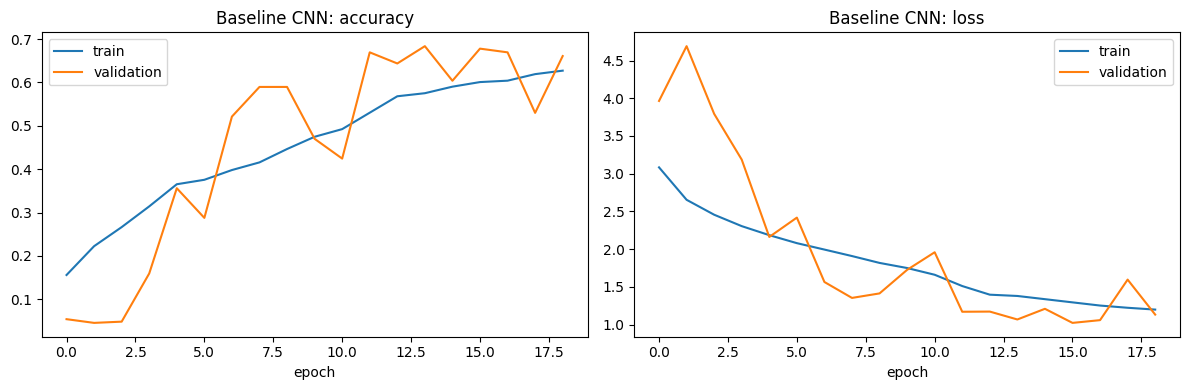

12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - accuracy: 0.6797 - loss: 1.0719
Baseline CNN – test accuracy: 0.6797


In [14]:
def plot_history(history, title):
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    axes[0].plot(history.history["accuracy"], label="train")
    axes[0].plot(history.history["val_accuracy"], label="validation")
    axes[0].set_title(f"{title}: accuracy")
    axes[0].set_xlabel("epoch")
    axes[0].legend()

    axes[1].plot(history.history["loss"], label="train")
    axes[1].plot(history.history["val_loss"], label="validation")
    axes[1].set_title(f"{title}: loss")
    axes[1].set_xlabel("epoch")
    axes[1].legend()
    plt.tight_layout()
    plt.show()

plot_history(baseline_history, "Baseline CNN")
baseline_test_loss, baseline_test_acc = baseline_model.evaluate(test_ds)
print(f"Baseline CNN – test accuracy: {baseline_test_acc:.4f}")

## 6. Transfer learning (MobileNetV2)

Датасет небольшой (~100 изображений на класс в train), поэтому дообучение предобученной на ImageNet сети обычно даёт заметно более высокую точность, чем CNN "с нуля". MobileNetV2 выбран как компактная и быстрая архитектура – удобно для последующего инференса в веб-сервисе.

### 6.1 Этап 1 – обучаем только "голову" (feature extraction)

In [15]:
def build_transfer_model(num_classes, base_trainable=False, fine_tune_at=None):
    base_model = tf.keras.applications.MobileNetV2(
        input_shape=(*IMG_SIZE, 3),
        include_top=False,
        weights="imagenet",
    )
    base_model.trainable = base_trainable
    if base_trainable and fine_tune_at is not None:
        for layer in base_model.layers[:fine_tune_at]:
            layer.trainable = False

    inputs = tf.keras.Input(shape=(*IMG_SIZE, 3))
    x = data_augmentation(inputs)
    x = tf.keras.applications.mobilenet_v2.preprocess_input(x)
    x = base_model(x, training=False)
    x = tf.keras.layers.GlobalAveragePooling2D()(x)
    x = tf.keras.layers.Dropout(0.3)(x)
    outputs = tf.keras.layers.Dense(num_classes, activation="softmax")(x)

    model = tf.keras.Model(inputs, outputs, name="mobilenetv2_transfer")
    return model, base_model

transfer_model, base_model = build_transfer_model(NUM_CLASSES, base_trainable=False)
transfer_model.compile(
    optimizer=tf.keras.optimizers.Adam(1e-3),
    loss="categorical_crossentropy",
    metrics=["accuracy"],
)
transfer_model.summary()

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step


Model: "mobilenetv2_transfer"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_3 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ data_augmentation (Sequential)  │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ true_divide (TrueDivide)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ subtract (Subtract)             │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 36)             │        46,116 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,304,100 (8.79 MB)

 Trainable params: 46,116 (180.14 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [16]:
head_history = transfer_model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=15,
    class_weight=class_weight,
    callbacks=callbacks,
)

Epoch 1/15
98/98 ━━━━━━━━━━━━━━━━━━━━ 14s 80ms/step - accuracy: 0.4584 - loss: 2.0873 - val_accuracy: 0.7977 - val_loss: 0.7647 - learning_rate: 0.0010
Epoch 2/15
98/98 ━━━━━━━━━━━━━━━━━━━━ 6s 61ms/step - accuracy: 0.7188 - loss: 0.9511 - val_accuracy: 0.8604 - val_loss: 0.5062 - learning_rate: 0.0010
Epoch 3/15
98/98 ━━━━━━━━━━━━━━━━━━━━ 6s 58ms/step - accuracy: 0.7759 - loss: 0.7455 - val_accuracy: 0.8547 - val_loss: 0.4220 - learning_rate: 0.0010
Epoch 4/15
98/98 ━━━━━━━━━━━━━━━━━━━━ 6s 62ms/step - accuracy: 0.8093 - loss: 0.6197 - val_accuracy: 0.8946 - val_loss: 0.3640 - learning_rate: 0.0010
Epoch 5/15
98/98 ━━━━━━━━━━━━━━━━━━━━ 6s 60ms/step - accuracy: 0.8228 - loss: 0.5628 - val_accuracy: 0.9117 - val_loss: 0.3157 - learning_rate: 0.0010
Epoch 6/15
98/98 ━━━━━━━━━━━━━━━━━━━━ 6s 62ms/step - accuracy: 0.8421 - loss: 0.4866 - val_accuracy: 0.8974 - val_loss: 0.2911 - learning_rate: 0.0010
Epoch 7/15
98/98 ━━━━━━━━━━━━━━━━━━━━ 6s 59ms/step - accuracy: 0.8623 - loss: 0.4576 - val_ac

### 6.2 Этап 2 – fine-tuning верхних слоёв базовой сети

Размораживаем последние слои MobileNetV2 и дообучаем всю модель целиком с маленьким learning rate, чтобы не разрушить предобученные веса.

In [19]:
base_model.trainable = True
FINE_TUNE_AT = len(base_model.layers) - 30  # размораживаем последние ~30 слоёв
for layer in base_model.layers[:FINE_TUNE_AT]:
    layer.trainable = False

transfer_model.compile(
    optimizer=tf.keras.optimizers.Adam(1e-5),
    loss="categorical_crossentropy",
    metrics=["accuracy"],
)

FINE_TUNE_EPOCHS = 15
total_epochs = head_history.epoch[-1] + 1 + FINE_TUNE_EPOCHS

fine_tune_history = transfer_model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=total_epochs,          # было epochs=15
    initial_epoch=head_history.epoch[-1] + 1,
    class_weight=class_weight,
    callbacks=callbacks,
)


Epoch 16/30
98/98 ━━━━━━━━━━━━━━━━━━━━ 21s 98ms/step - accuracy: 0.7474 - loss: 0.7892 - val_accuracy: 0.9231 - val_loss: 0.2146 - learning_rate: 1.0000e-05
Epoch 17/30
98/98 ━━━━━━━━━━━━━━━━━━━━ 7s 76ms/step - accuracy: 0.7881 - loss: 0.6539 - val_accuracy: 0.9231 - val_loss: 0.2147 - learning_rate: 1.0000e-05
Epoch 18/30
98/98 ━━━━━━━━━━━━━━━━━━━━ 8s 78ms/step - accuracy: 0.8228 - loss: 0.5640 - val_accuracy: 0.9316 - val_loss: 0.2119 - learning_rate: 1.0000e-05
Epoch 19/30
98/98 ━━━━━━━━━━━━━━━━━━━━ 8s 79ms/step - accuracy: 0.8437 - loss: 0.4931 - val_accuracy: 0.9288 - val_loss: 0.2042 - learning_rate: 1.0000e-05
Epoch 20/30
98/98 ━━━━━━━━━━━━━━━━━━━━ 8s 78ms/step - accuracy: 0.8510 - loss: 0.4443 - val_accuracy: 0.9345 - val_loss: 0.1983 - learning_rate: 1.0000e-05


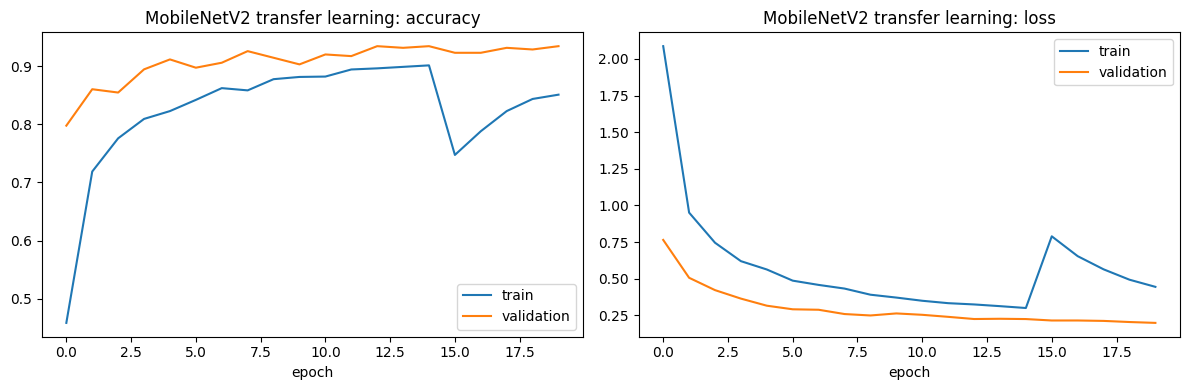

12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 77ms/step - accuracy: 0.9220 - loss: 0.2171
MobileNetV2 (fine-tuned) – test accuracy: 0.9220
Baseline CNN – test accuracy: 0.6797


In [20]:
def merge_histories(h1, h2):
    merged = {}
    for k in h1.history:
        merged[k] = h1.history[k] + h2.history[k]
    class Merged:
        pass
    m = Merged()
    m.history = merged
    return m

full_transfer_history = merge_histories(head_history, fine_tune_history)
plot_history(full_transfer_history, "MobileNetV2 transfer learning")

transfer_test_loss, transfer_test_acc = transfer_model.evaluate(test_ds)
print(f"MobileNetV2 (fine-tuned) – test accuracy: {transfer_test_acc:.4f}")
print(f"Baseline CNN – test accuracy: {baseline_test_acc:.4f}")

## 7. Подбор гиперпараметров

Небольшой перебор learning rate и dropout для "головы" transfer-модели (без полного fine-tuning – чтобы эксперимент был быстрым). Выбираем конфигурацию с лучшей `val_accuracy`, затем при желании повторяем полное обучение (разделы 6.1–6.2) с найденными параметрами.

In [21]:
def build_head_only_model(num_classes, dropout):
    base = tf.keras.applications.MobileNetV2(
        input_shape=(*IMG_SIZE, 3), include_top=False, weights="imagenet"
    )
    base.trainable = False
    inputs = tf.keras.Input(shape=(*IMG_SIZE, 3))
    x = data_augmentation(inputs)
    x = tf.keras.applications.mobilenet_v2.preprocess_input(x)
    x = base(x, training=False)
    x = tf.keras.layers.GlobalAveragePooling2D()(x)
    x = tf.keras.layers.Dropout(dropout)(x)
    outputs = tf.keras.layers.Dense(num_classes, activation="softmax")(x)
    return tf.keras.Model(inputs, outputs)

results = []
for lr in [1e-3, 5e-4]:
    for dropout in [0.2, 0.4]:
        tf.keras.backend.clear_session()
        m = build_head_only_model(NUM_CLASSES, dropout)
        m.compile(
            optimizer=tf.keras.optimizers.Adam(lr),
            loss="categorical_crossentropy",
            metrics=["accuracy"],
        )
        h = m.fit(train_ds, validation_data=val_ds, epochs=5, verbose=0)
        best_val_acc = max(h.history["val_accuracy"])
        results.append({"lr": lr, "dropout": dropout, "val_accuracy": best_val_acc})
        print(f"lr={lr}, dropout={dropout} -> val_accuracy={best_val_acc:.4f}")

best_config = max(results, key=lambda r: r["val_accuracy"])
print("Лучшая конфигурация:", best_config)

lr=0.001, dropout=0.2 -> val_accuracy=0.9031
lr=0.001, dropout=0.4 -> val_accuracy=0.9088
lr=0.0005, dropout=0.2 -> val_accuracy=0.8718
lr=0.0005, dropout=0.4 -> val_accuracy=0.8519
Лучшая конфигурация: {'lr': 0.001, 'dropout': 0.4, 'val_accuracy': 0.9088318943977356}


## 8. Итоговая валидация модели

Берём лучшую из обученных моделей (`transfer_model` после fine-tuning) и подробно оцениваем её на test-выборке: confusion matrix и classification report (precision/recall/F1 по каждому классу).

In [22]:
y_true = []
y_pred = []

for images, labels in test_ds:
    preds = transfer_model.predict(images, verbose=0)
    y_true.extend(np.argmax(labels.numpy(), axis=1))
    y_pred.extend(np.argmax(preds, axis=1))

print(classification_report(y_true, y_pred, target_names=class_names))

               precision    recall  f1-score   support

        apple       0.73      0.80      0.76        10
       banana       1.00      0.78      0.88         9
     beetroot       1.00      1.00      1.00        10
  bell pepper       0.69      0.90      0.78        10
      cabbage       1.00      1.00      1.00        10
     capsicum       0.67      0.60      0.63        10
       carrot       0.90      0.90      0.90        10
  cauliflower       1.00      1.00      1.00        10
chilli pepper       0.80      0.80      0.80        10
         corn       1.00      0.30      0.46        10
     cucumber       0.91      1.00      0.95        10
     eggplant       1.00      1.00      1.00        10
       garlic       1.00      1.00      1.00        10
       ginger       1.00      1.00      1.00        10
       grapes       1.00      0.80      0.89        10
     jalepeno       0.90      0.90      0.90        10
         kiwi       1.00      1.00      1.00        10
        l

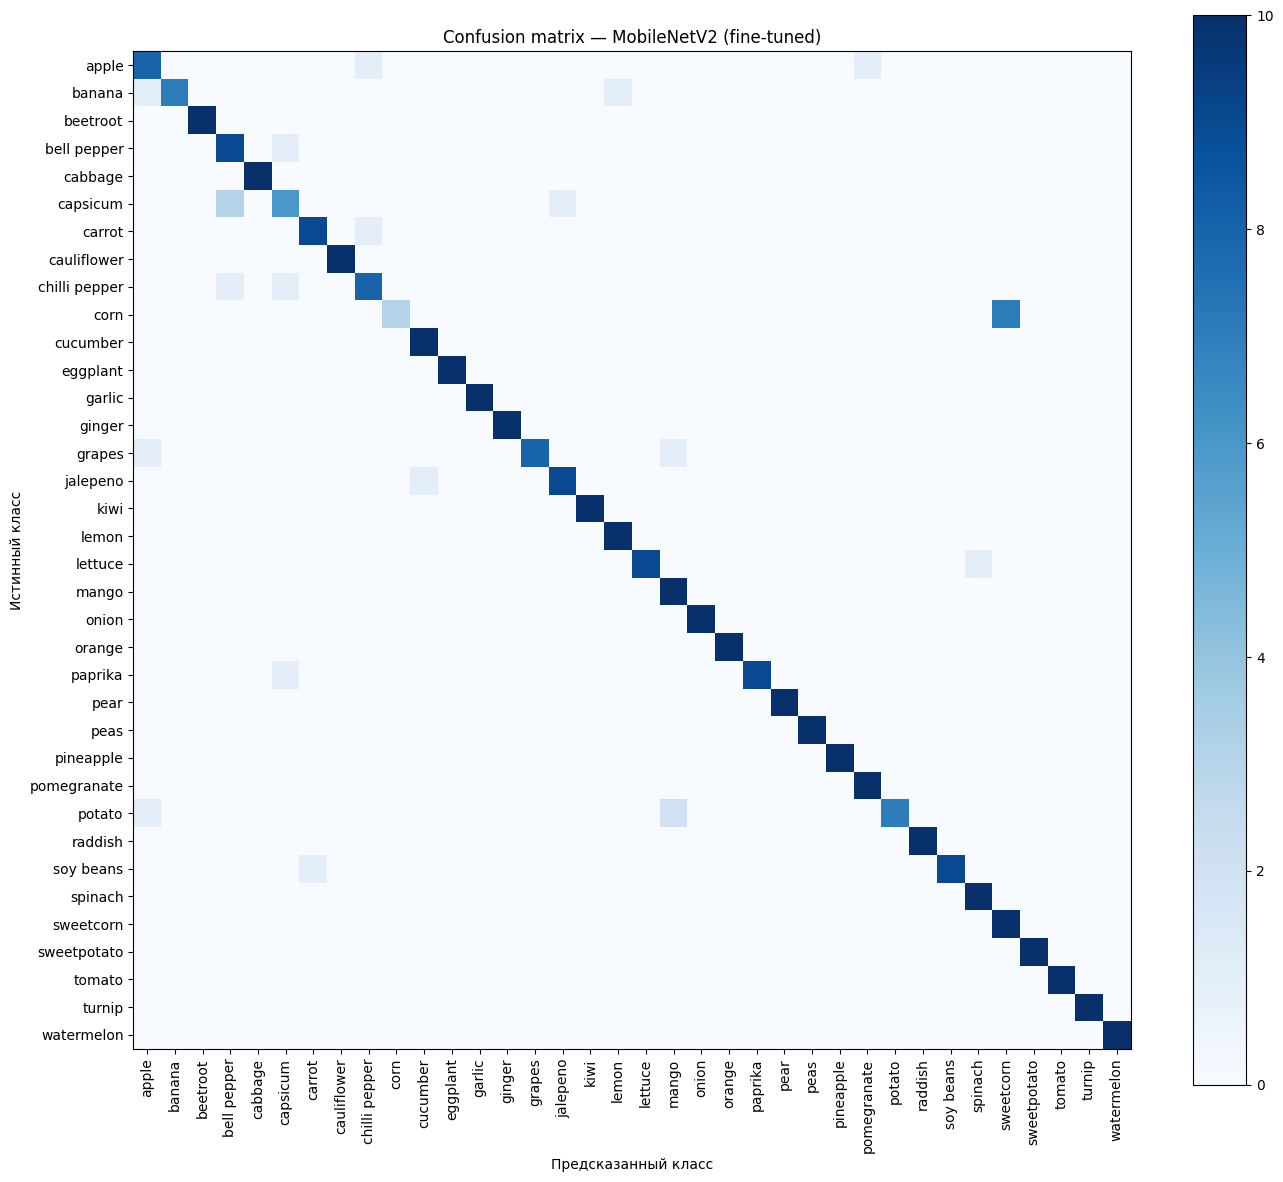

In [23]:
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(14, 12))
plt.imshow(cm, cmap="Blues")
plt.colorbar()
plt.xticks(range(NUM_CLASSES), class_names, rotation=90)
plt.yticks(range(NUM_CLASSES), class_names)
plt.xlabel("Предсказанный класс")
plt.ylabel("Истинный класс")
plt.title("Confusion matrix – MobileNetV2 (fine-tuned)")
plt.tight_layout()
plt.show()

## 9. Экспорт модели для веб-сервиса

Сохраняем:
- саму модель (`.keras` – нативный формат Keras 3, поддерживается TensorFlow Serving/TFLite конвертацией);
- `class_names.json` – соответствие индекс → название класса, оно понадобится бэкенду, чтобы превратить выход softmax в человекочитаемую метку;
- `model_info.json` – размер входного изображения и способ препроцессинга, чтобы бэкенд готовил изображение точно так же, как при обучении.

In [24]:
EXPORT_DIR = pathlib.Path("/content/export")
EXPORT_DIR.mkdir(exist_ok=True)

model_path = EXPORT_DIR / "fruit_veg_classifier.keras"
transfer_model.save(model_path)

with open(EXPORT_DIR / "class_names.json", "w", encoding="utf-8") as f:
    json.dump(class_names, f, ensure_ascii=False, indent=2)

model_info = {
    "image_size": list(IMG_SIZE),
    "preprocessing": "mobilenet_v2.preprocess_input (expects RGB uint8 [0,255] input, scaling handled inside the model)",
    "num_classes": NUM_CLASSES,
    "test_accuracy": float(transfer_test_acc),
}
with open(EXPORT_DIR / "model_info.json", "w", encoding="utf-8") as f:
    json.dump(model_info, f, ensure_ascii=False, indent=2)

print("Сохранено в:", EXPORT_DIR)
print(os.listdir(EXPORT_DIR))

Сохранено в: /content/export
['class_names.json', 'fruit_veg_classifier.keras', 'model_info.json']


In [27]:
from google.colab import files

# Скачиваем архив с артефактами модели на локальный диск –
# понадобится для бэкенда веб-сервиса на следующем этапе.
shutil.make_archive("/content/fruit_veg_model_export", "zip", EXPORT_DIR)
files.download("/content/fruit_veg_model_export.zip")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

### (опционально) Сохранение в Google Drive

Если планируешь продолжать работу в другой сессии Colab, удобнее сохранить экспорт сразу в Google Drive, а не скачивать архив вручную каждый раз.

In [ ]:
# from google.colab import drive
# drive.mount('/content/drive')
# shutil.copytree(EXPORT_DIR, '/content/drive/MyDrive/fruit_veg_model_export', dirs_exist_ok=True)

## 10. Проверка инференса (как это будет работать в бэкенде)

Загружаем сохранённую модель "с нуля" и прогоняем одно изображение из test – именно так бэкенд будет обрабатывать загруженную пользователем картинку.

Файл: /content/data/test/apple/Image_3.jpg
Предсказанный класс: apple (уверенность 72.69%)


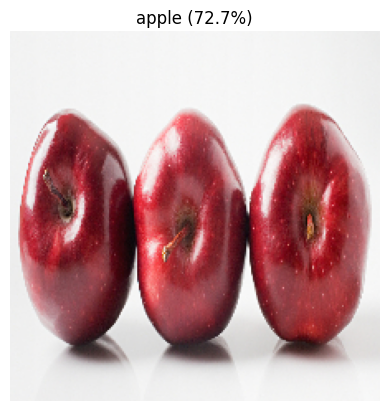

In [28]:
loaded_model = tf.keras.models.load_model(model_path)

sample_path = next((TEST_DIR / class_names[0]).glob("*"))
img = tf.keras.utils.load_img(sample_path, target_size=IMG_SIZE)
img_array = tf.keras.utils.img_to_array(img)
img_array = tf.expand_dims(img_array, 0)  # добавляем batch-размерность

pred = loaded_model.predict(img_array, verbose=0)[0]
top_idx = int(np.argmax(pred))

print(f"Файл: {sample_path}")
print(f"Предсказанный класс: {class_names[top_idx]} (уверенность {pred[top_idx]:.2%})")
plt.imshow(img)
plt.title(f"{class_names[top_idx]} ({pred[top_idx]:.1%})")
plt.axis("off")
plt.show()